# Problem 2 and 3 Solution

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tqdm
import time
import os

In [2]:
def build_mlp(input_dim, n_layers, hidden_units, output_dim):
    """Build an MLP with `n_layers` hidden linear+ReLU layers and a linear output.

    Returns
    -------
    nn.Module
        The constructed MLP.
    """
    layers = []
    # BEGIN YOUR CODE HERE (~5-6 lines)
    for i in range(n_layers):
        if i == 0:
            layers.append(nn.Linear(input_dim, hidden_units))
        else:
            layers.append(nn.Linear(hidden_units, hidden_units))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(hidden_units, output_dim))
    # END YOUR CODE HERE
    return nn.Sequential(*layers)

In [3]:
def extract_model_params(model):
    """Extract all parameters of a PyTorch model."""
    return torch.cat([p.view(-1) for p in model.parameters() if p.requires_grad])

def load_params_into_model(model, all_params):
    """Loads a flattened array of parameters back into a PyTorch model."""
    current_pos = 0
    for param in model.parameters():
        if param.requires_grad:
            num_params = param.numel()
            # Reshape the flattened parameters to the original shape of the parameter
            param.data.copy_(all_params[current_pos : current_pos + num_params].view(param.size()))
            current_pos += num_params

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        # BEGIN YOUR CODE HERE (~5-7 lines)
        logits = model(X)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # END YOUR CODE HERE
        running_loss += loss.item() * X.size(0)

    # Extract and store the model parameters after the epoch
    all_params = extract_model_params(model)

    return running_loss / len(loader.dataset), all_params.detach().cpu().numpy()


def evaluate(model, loader):
    # model.eval()
    correct = 0
    total = 0
    # with torch.no_grad():
    for X, y in loader:
        # BEGIN YOUR CODE HERE (~4 lines)
        logits = model(X)
        predictions = torch.argmax(logits, dim=1)
        total += y.size(0)
        correct += (predictions == y).sum().item()
        # END YOUR CODE HERE

    return correct / total


def compute_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            # BEGIN YOUR CODE HERE (~3 lines)
            logits = model(X)
            loss = criterion(logits, y)
            running_loss += loss.item() * X.size(0)
            # END YOUR CODE HERE
    return running_loss / len(loader.dataset)




# compute_loss performs forward pass and accumulates loss correctly over the loader.

In [5]:
def hyperparam_tuning(train_dataset, val_dataset, seed=541):
    """Systematically search hyperparameters and return the best config and model state.

    Returns
    -------
    dict, state_dict
        Best hyperparameters and the corresponding model state dict.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    best_cfg = None
    best_acc = 0.0
    # BEGIN YOUR CODE HERE (~15-20 lines)
    hidden_layers = [3, 4, 5]
    hidden_units = [40, 50, 60]
    learning_rates = [0.1, 0.01]
    batch_sizes = [32, 64] 
    epochs = 10

    for n_layers in hidden_layers:
        for hidden_unit in hidden_units:
            for lr in learning_rates:
                for batch_size in batch_sizes:
                    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                    model = build_mlp(input_dim=784, n_layers=n_layers, hidden_units=hidden_unit, output_dim=10)
                    criterion = nn.CrossEntropyLoss()
                    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

                    for epoch in tqdm.tqdm(range(epochs), desc=f"Training model with layers={n_layers}, units={hidden_unit}, lr={lr}, batch_size={batch_size}"):
                        loss, params = train_epoch(model, train_loader, criterion, optimizer)

                    train_loss = compute_loss(model, train_loader, criterion)
                    val_loss = compute_loss(model, val_loader, criterion)

                    training_acc = evaluate(model, train_loader)
                    val_acc = evaluate(model, val_loader)
                    # print(f'Training Loss: {loss:.4f}, Training Accuracy: {training_acc:.4f}, Validation Accuracy: {val_acc:.4f}')

                    if val_acc > best_acc:
                        best_acc = val_acc
                        best_cfg = {
                            'n_layers': n_layers,
                            'hidden_units': hidden_unit,
                            'lr': lr,
                            'batch_size': batch_size,
                            'training_loss': train_loss,
                            'validation_loss': val_loss,
                            'training_acc': training_acc,
                            'training_params': params
                        }
                        # best_cfg = model.state_dict()  # Store the best model's state_dict
    # END YOUR CODE HERE

    return best_cfg, best_acc

In [6]:
# Load data (numpy arrays assumed present in workspace)
X_train = np.load("data/fashion_mnist_train_images.npy").astype(np.float32) / 255.0
y_train = np.load("data/fashion_mnist_train_labels.npy").astype(np.int64)
X_test = np.load("data/fashion_mnist_test_images.npy").astype(np.float32) / 255.0
y_test = np.load("data/fashion_mnist_test_labels.npy").astype(np.int64)

# Flatten if images are HxW
if X_train.ndim == 3:
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

# center data similarly to previous versions
X_train = X_train - 0.5
X_test = X_test - 0.5

# Convert to tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

# Train/val split
full_train = TensorDataset(X_train_t, y_train_t)
val_size = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])


# Run hyperparameter tuning
best_cfg, best_acc = hyperparam_tuning(train_dataset, val_dataset)
print(f"Best config: {best_cfg}\nval_acc={best_acc:.4f}")

Training model with layers=3, units=40, lr=0.1, batch_size=32: 100%|██████████| 10/10 [00:04<00:00,  2.24it/s]
Training model with layers=3, units=40, lr=0.1, batch_size=64: 100%|██████████| 10/10 [00:02<00:00,  3.37it/s]
Training model with layers=3, units=40, lr=0.01, batch_size=32: 100%|██████████| 10/10 [00:04<00:00,  2.29it/s]
Training model with layers=3, units=40, lr=0.01, batch_size=64: 100%|██████████| 10/10 [00:02<00:00,  3.47it/s]
Training model with layers=3, units=50, lr=0.1, batch_size=32: 100%|██████████| 10/10 [00:04<00:00,  2.27it/s]
Training model with layers=3, units=50, lr=0.1, batch_size=64: 100%|██████████| 10/10 [00:02<00:00,  3.37it/s]
Training model with layers=3, units=50, lr=0.01, batch_size=32: 100%|██████████| 10/10 [00:04<00:00,  2.26it/s]
Training model with layers=3, units=50, lr=0.01, batch_size=64: 100%|██████████| 10/10 [00:03<00:00,  3.32it/s]
Training model with layers=3, units=60, lr=0.1, batch_size=32: 100%|██████████| 10/10 [00:04<00:00,  2.25it/

Best config: {'n_layers': 4, 'hidden_units': 40, 'lr': 0.1, 'batch_size': 32, 'training_loss': 0.27907218227535485, 'validation_loss': 0.3319734184940656, 'training_acc': 0.8980833333333333, 'training_params': array([ 0.1437881 ,  0.08617827,  0.13800938, ..., -0.29222283,
        0.6349547 , -0.6985764 ], dtype=float32)}
val_acc=0.8860


In [29]:
# Retrain best model on full training set (train+val) for more epochs
n_features = X_train.shape[1]
n_classes = int(y_train.max() + 1)
# Instantiate the best model
# BEGIN YOUR CODE HERE (~3 lines)
best_model = build_mlp(input_dim=n_features, n_layers=best_cfg['n_layers'], hidden_units=best_cfg['hidden_units'], output_dim=n_classes)
load_params_into_model(best_model, torch.tensor(best_cfg['training_params'], dtype=torch.float32))

# create full training loader and test loader
batch_size = X_train.shape[0]
full_train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(best_model.parameters(), lr=best_cfg['lr']*0.1)

In [30]:
# retrain best model
epochs_final = 50
parameter_history = []  # To store the history of parameters
training_loss_history = []  # To store the history of training loss
epoch_history = []  # To store the history of epochs
test_acc_history = []  # To store the history of test accuracy
for epoch in range(epochs_final):
    # BEGIN YOUR CODE HERE (~2 lines)
    t0 = time.time()
    loss, all_params = train_epoch(best_model, full_train_loader, criterion, optimizer)
    training_loss = compute_loss(best_model, full_train_loader, criterion)  # Compute training loss after the epoch
    parameter_history.append(all_params)  # Store the parameters after each epoch
    training_loss_history.append(training_loss)  # Store the training loss after each epoch
    epoch_history.append(epoch + 1)  # Store the epoch number
    test_acc = evaluate(best_model, test_loader)
    test_acc_history.append(test_acc)  # Store the test accuracy after each epoch
    t1 = time.time()
    # END YOUR CODE HERE
    print(f"Final Train Epoch {epoch+1}/{epochs_final}: loss={loss:.4f}, test_acc={test_acc:.4f}, time={t1-t0:.1f}s")

Final Train Epoch 1/50: loss=0.2897, test_acc=0.8722, time=0.9s
Final Train Epoch 2/50: loss=0.2889, test_acc=0.8722, time=0.7s
Final Train Epoch 3/50: loss=0.2881, test_acc=0.8726, time=0.7s
Final Train Epoch 4/50: loss=0.2874, test_acc=0.8725, time=0.7s
Final Train Epoch 5/50: loss=0.2868, test_acc=0.8727, time=0.7s
Final Train Epoch 6/50: loss=0.2862, test_acc=0.8730, time=0.7s
Final Train Epoch 7/50: loss=0.2856, test_acc=0.8735, time=0.7s
Final Train Epoch 8/50: loss=0.2850, test_acc=0.8733, time=0.7s
Final Train Epoch 9/50: loss=0.2845, test_acc=0.8734, time=0.7s
Final Train Epoch 10/50: loss=0.2840, test_acc=0.8734, time=0.7s
Final Train Epoch 11/50: loss=0.2836, test_acc=0.8734, time=0.8s
Final Train Epoch 12/50: loss=0.2831, test_acc=0.8735, time=0.8s
Final Train Epoch 13/50: loss=0.2827, test_acc=0.8737, time=0.7s
Final Train Epoch 14/50: loss=0.2823, test_acc=0.8739, time=0.8s
Final Train Epoch 15/50: loss=0.2819, test_acc=0.8736, time=0.8s
Final Train Epoch 16/50: loss=0.28

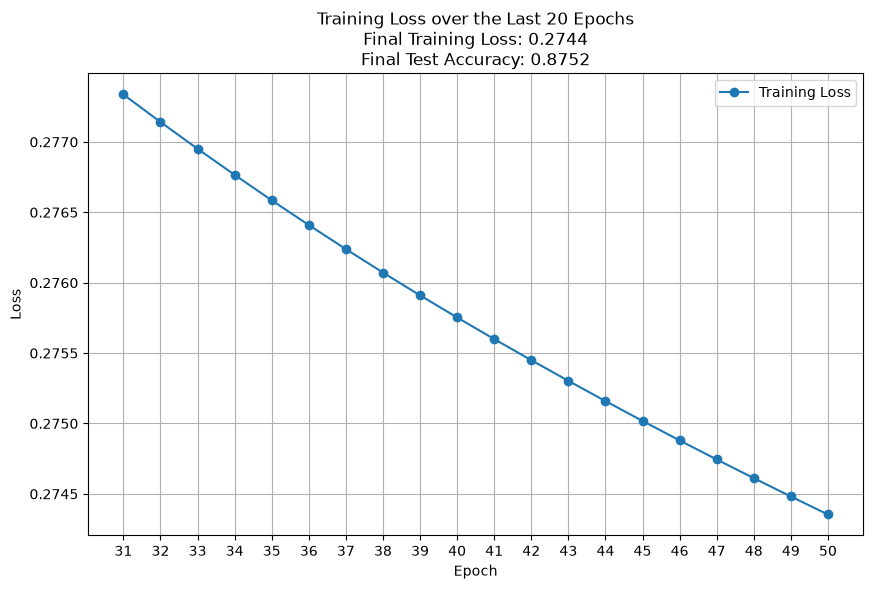

In [121]:
# plot training loss over the last 20 epochs
plt.figure(figsize=(10, 6))
plt.plot(epoch_history[-20:], training_loss_history[-20:], marker='o', label='Training Loss')

plt.title(f'Training Loss over the Last 20 Epochs\nFinal Training Loss: {training_loss_history[-1]:.4f}\nFinal Test Accuracy: {test_acc_history[-1]:.4f}')
plt.xticks(epoch_history[-20:])  # Set x-ticks to the last 20 epochs
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

In [12]:
# Print the length of the parameter_history list
print(f"Length of parameter history: {len(parameter_history)}\nShape of each parameter vector: {parameter_history[0].shape if parameter_history else 'N/A'}")

Length of parameter history: 50
Shape of each parameter vector: (36730,)


In [ ]:
# def plotPath(loader, trajectory, model):
#     # TODO: change this toy plot to show a 2-d projection of the weight space
#     # along with the associated loss (cross-entropy), plus a superimposed 
#     # trajectory across the landscape that was traversed using SGD. Use
#     # sklearn.decomposition.PCA's fit_transform and inverse_transform methods.

#     model.eval()  # Set the model to evaluation mode
#     trajectory = np.asarray(trajectory)
#     pca = PCA(n_components=2)
#     trajectory_2d = pca.fit_transform(trajectory)

#     def toyFunction (pc1, pc2):
#         point_2d = np.array([[pc1, pc2]])
#         weights = pca.inverse_transform(point_2d)[0]
#         load_params_into_model(model, torch.tensor(weights, dtype=torch.float32))
#         loss = compute_loss(model, loader, criterion)
#         return loss
        
#     fig = plt.figure()
#     ax = fig.add_subplot(projection='3d')

#     # Compute the CE loss on a grid of points (corresonding to different w).
#     axis1 = np.arange(-20, 20, 0.05)  # Just an example
#     axis2 = np.arange(-10, 10, 0.05)  # Just an example
#     Xaxis, Yaxis = np.meshgrid(axis1, axis2)
#     Zaxis = np.zeros((len(axis1), len(axis2)))
#     for i in tqdm.tqdm(range(len(axis1))):
#         for j in range(len(axis2)):
#             Zaxis[i,j] = toyFunction(Xaxis[i, j], Yaxis[i, j])
#     ax.plot_surface(Xaxis, Yaxis, Zaxis, alpha=0.6)  # Keep alpha < 1 so we can see the scatter plot too.

#     # Now superimpose a scatter plot showing the weights during SGD.
#     Xaxis = 2*np.pi*np.random.random(8) - np.pi  # Just an example
#     Yaxis = 2*np.pi*np.random.random(8) - np.pi  # Just an example
#     Zaxis = toyFunction(Xaxis, Yaxis)
#     ax.scatter(Xaxis, Yaxis, Zaxis, color='r')

#     plt.show()

# plotPath(full_train_loader,parameter_history,best_model)

In [133]:
### This is the part to be verified ######


def plotPath(loader, trajectory, model):
    model.eval()

    trajectory = np.asarray(trajectory)
    pca = PCA(n_components=2)
    trajectory_2d = pca.fit_transform(trajectory)

    def toyFunction(pc1, pc2):
        point_2d = np.asarray([pc1, pc2])
        weights = pca.inverse_transform(point_2d)

        load_params_into_model(
            model,
            torch.tensor(weights, dtype=torch.float32)
        )

        return compute_loss(model, loader, nn.CrossEntropyLoss())

    # Create a grid in PCA coordinates
    pc1_values = np.linspace(
        -20, 20, 10
    )
    pc2_values = np.linspace(
        -10, 10, 10
    )

    PC1, PC2 = np.meshgrid(pc1_values, pc2_values)
    LOSS = np.zeros((len(pc1_values), len(pc2_values)))

    for i in tqdm.tqdm(range(len(pc1_values)), desc="Computing loss surface"):
        for j in range(len(pc2_values)):
            LOSS[i, j] = toyFunction(PC1[i, j], PC2[i, j])

    # Compute losses at the actual SGD weight vectors
    trajectory_losses = []

    # for weights in trajectory:
    #     load_params_into_model(
    #         model,
    #         torch.tensor(weights, dtype=torch.float32)
    #     )
    #     trajectory_losses.append(
    #         compute_loss(model, loader, nn.CrossEntropyLoss())
    #     )
    Xaxis = np.linspace(0, 8, 10)
    Yaxis = np.linspace(0, 8, 10)
    for x, y in zip(Xaxis, Yaxis):
        trajectory_losses.append(toyFunction(x, y))

    trajectory_losses = np.asarray(trajectory_losses)

    # Restore the final model
    load_params_into_model(
        model,
        torch.tensor(trajectory[-1], dtype=torch.float32)
    )

    # Plot loss surface and SGD scatter points
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection="3d")

    ax.plot_surface(
        PC1,
        PC2,
        LOSS,
        cmap="viridis",
        alpha=0.6
    )

    ax.scatter(
       Xaxis,
        Yaxis,
        trajectory_losses,
        color="red",
        s=40,
        label="SGD weights"
    )

    ax.plot(
        Xaxis,
        Yaxis,
        trajectory_losses,
        color="red",
        alpha=0.7
    )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_zlabel("Cross-Entropy Loss")
    ax.set_title("Loss Landscape with SGD Weight Trajectory")
    ax.legend()

    plt.show()

Computing loss surface: 100%|██████████| 10/10 [00:34<00:00,  3.41s/it]


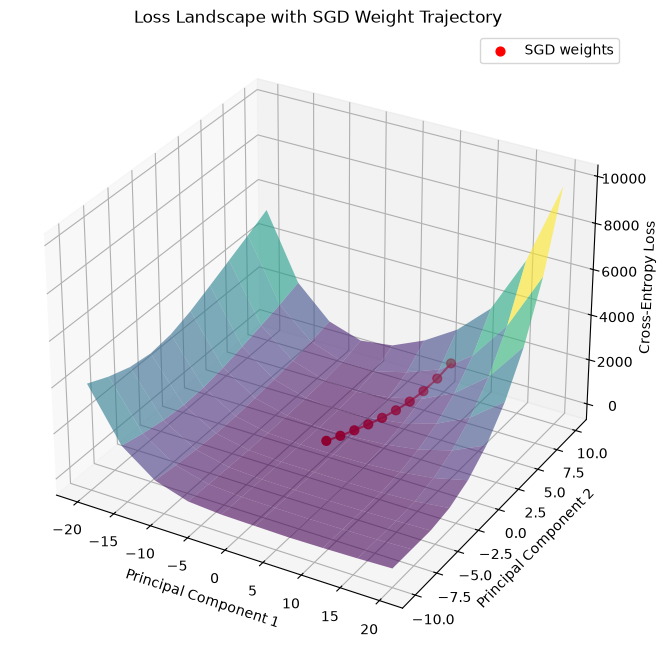

In [134]:
plotPath(full_train_loader, parameter_history, best_model)

In [88]:
def toyFunction (loader, trajectory, model):
    trajectory = np.asarray(trajectory)
    #apply PCA to reduce the dimensionality of the trajectory to 2D
    pca = PCA(n_components=2)
    trajectory_2d = pca.fit_transform(trajectory)
    
    # Compute the loss for each point in the 2D trajectory
    losses = []
    for point in trajectory_2d:
        # Inverse transform to get back to the original parameter space
        original_params = pca.inverse_transform(point)
        load_params_into_model(model, torch.tensor(original_params, dtype=torch.float32))
        loss = compute_loss(model, loader, nn.CrossEntropyLoss())
        losses.append(loss)
    return trajectory_2d ,losses

trajectroy_2d, losses = toyFunction(full_train_loader, parameter_history, best_model)


In [90]:
trajectroy_2d[:5], losses[:5]  # Display the first 5 points and their corresponding lossestr

trajectroy_2d.shape

(50, 2)

In [111]:
def do_pca_projection(trajectory, n_components=2):
    """Fit PCA to a parameter trajectory and return its projection and fitted PCA."""
    trajectory = np.asarray(trajectory)
    pca = PCA(n_components=n_components)
    trajectory_2d = pca.fit_transform(trajectory)
    return trajectory_2d, pca


def do_inverse_pca_projection(trajectory_2d, pca):
    """Map PCA coordinates back using the already-fitted PCA transformer."""
    trajectory_2d = np.asarray(trajectory_2d)
    return pca.inverse_transform(trajectory_2d)

In [ ]:
pca_2d, fitted_pca = do_pca_projection(parameter_history, n_components=2)
pca_2d[:5]  # Display the first 5 points of the PCA projection

array([[0.04601086, 0.00524056],
       [0.04341539, 0.00438109],
       [0.04088536, 0.00358565],
       [0.0384235 , 0.00285491],
       [0.03602214, 0.00218402]], dtype=float32)

In [116]:
inverse_pca_trajectory = do_inverse_pca_projection(pca_2d, pca)
inverse_pca_trajectory[:5], inverse_pca_trajectory.shape  # Display the first 5 points of the inverse PCA projection

(array([[ 0.14376485,  0.08615554,  0.13798667, ..., -0.29219025,
          0.634974  , -0.69856447],
        [ 0.14374244,  0.08613306,  0.13796419, ..., -0.2921534 ,
          0.63499194, -0.6985517 ],
        [ 0.14372034,  0.08611088,  0.13794202, ..., -0.29211742,
          0.6350095 , -0.6985397 ],
        [ 0.14369857,  0.08608904,  0.13792019, ..., -0.2920824 ,
          0.6350268 , -0.69852835],
        [ 0.14367709,  0.08606749,  0.13789864, ..., -0.29204822,
          0.63504374, -0.6985177 ]], dtype=float32),
 (50, 36730))